In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
from time import time
from pathlib import Path
import copy


from umap import UMAP
import leidenalg as la

import anndata as ad
import scanpy as sc


from tysserand import tysserand as ty
from mosna import mosna





## Paramètres et données

In [304]:
# =====================================================
# Cell types d'intérêt
# =====================================================

state_type = 'niche' # leiden or niche
all = True
cell_interest = "Tumour Cells" # "Macrophages' states" or "Tumour Cells"

tumour_mode = "double_status"      # marker ou "double_status"
marker = "corrected_double_status_tumour"

n_neighbors = 15 #pour graph des voisin avant UMAP
n_pcs = None # nombre de pc utiliser dans graph voisin avant UMAP, si on ne veut pas utiliser la pca pour UMAP, mettre "None"
res = 0.9 #résolution leiden
threshold = 5 # threshold pour ARI et sankey plot = nombre minal de cellule pour prendre en compte un flux

if tumour_mode == "marker":

    celltypes_interest = [
        f"Tumour cells ({marker}-)",
        f"Tumour cells ({marker}+)",
        "Macrophage_state_0",
        "Macrophage_state_1",
        "Macrophage_state_2",
        "Macrophage_state_3",
        "CAF",
    ]

elif tumour_mode == "double_status":
    if cell_interest == "Macrophages' states" :
        celltypes_interest = [
            #"Tumour cells (KRT17- S100A2-)",
            #"Tumour cells (KRT17+ S100A2-)",
            #"Tumour cells (KRT17- S100A2+)",
            #"Tumour cells (KRT17+ S100A2+)",
            "Macrophage_state_4",
            "Macrophage_state_1",
            "Macrophage_state_2",
            "Macrophage_state_3",

            #"CAF",
        ]
    if cell_interest == "Tumour Cells" :
        celltypes_interest = [
            "Tumour cells (KRT17- S100A2-)",
            "Tumour cells (KRT17+ S100A2-)",
            "Tumour cells (KRT17- S100A2+)",
            "Tumour cells (KRT17+ S100A2+)",
            #"Mesenchymal tumour",
        ]


if all:

    if tumour_mode == "marker":
            celltypes_interest = [
                "B Cell",
                "CD4 T Cell",
                "CD8 T Cell",
                "DC",
                "Endothelial Cell",
                "Epithelial Cell",
                "Mesenchymal tumour",
                "Monocyte",
                f"Tumour cells ({marker}-)",
                f"Tumour cells ({marker}+)",
                "Macrophage_state_4",
                "Macrophage_state_1",
                "Macrophage_state_2",
                "Macrophage_state_3",
                "CAF",
                "Treg cell",
                "Unknown",
         ]
            

    elif tumour_mode == "double_status":

          celltypes_interest = [
                "B Cell",
                "CD4 T Cell",
                "CD8 T Cell",
                "DC",
                "Endothelial Cell",
                "Epithelial Cell",
                "Mesenchymal tumour",
                "Monocyte",
                "Tumour cells (KRT17- S100A2-)",
                "Tumour cells (KRT17+ S100A2-)",
                "Tumour cells (KRT17- S100A2+)",
                "Tumour cells (KRT17+ S100A2+)",
                "Macrophage_state_4",
                "Macrophage_state_1",
                "Macrophage_state_2",
                "Macrophage_state_3",
                "CAF",
                "Treg cell",
                "Unknown",
         ]


if all :
    extra = "/all"
else:
    if cell_interest == "Macrophages' states":
        extra = '/macrophages_states'
    elif cell_interest == "Tumour Cells":
        extra = "/tumour_cells"
    else :
        extra = ""
plot_save_dir = Path(f"OUTPUT_arcsinh/states/{marker}_and_macrostates_labeled/{state_type}_states/assortativity/500_shuffles/umap_pca{extra}/")
plot_save_dir.mkdir(parents=True, exist_ok=True)
# récup stats data sans le générer
save_dir = Path(f"./OUTPUT_arcsinh/states/{marker}_and_macrostates_labeled/{state_type}_states/assortativity/500_shuffles")
stats_data = pd.read_parquet(save_dir / "group_stats_data_assortativity.parquet")

#je récup métainfos
info_metadata_path = Path('./images_metadatainfo.csv')
metadata = pd.read_csv(info_metadata_path)

In [305]:
#Je recupère patient et sample en pour chaque ligne de metainfo data et je mets ça dans colonne image sachant que de la forme 4 derniers chiffre = 2 premiers patient, deux derniere sample

import re
metadata = metadata.copy()

metadata["patient"] = metadata["image"].str[6:8]
metadata["sample"] = metadata["image"].str[8:10]

metadata["id"] = "patient-" + metadata["patient"] + "_sample-" + metadata["sample"]


metadata = metadata.set_index('id')

metadata.index = (
    metadata.index
    .astype(str)
    .map(
        lambda x: re.sub(r'(\D)0+(\d+)', r'\1\2', x)
    )
)

metadata.head()

,image,width_px,height_px,num_channels,source_file,recovery_file,recovered,original image ID,Notes,Patient ID,For tumour only analysis,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample
id,,,,,,,,,,,,,,,,,,,,
patient-1_sample-3,hPDAC_0103,1968,1089,38,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,NaN,False,S0868_M Chihara-Slide_01_Dysplasia_x32670_y119...,dysplasia,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,03
patient-1_sample-4,hPDAC_0104,1395,1578,38,S0868_M Chihara-Slide_01_adjacent normal_x1679...,NaN,False,S0868_M Chihara-Slide_01_adjacent normal_x1679...,adjacent normal,A22TLYZ04-01,No,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,04
patient-1_sample-2,hPDAC_0102,1395,1578,38,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,NaN,False,S0868_M Chihara-Slide_01_adjacent stroma_x2139...,tumour stroma,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,02
patient-1_sample-1,hPDAC_0101,1439,1534,38,S0868_M Chihara-Slide_01_tumour centre_x20222_...,NaN,False,S0868_M Chihara-Slide_01_tumour centre_x20222_...,tumour centre,A22TLYZ04-01,Yes,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,01
patient-2_sample-3,hPDAC_0203,1432,1472,38,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,NaN,False,S0869_M Chihara-Slide_02_adjacent stroma_1_x31...,tumour stroma,A22TLYZ04-02,Yes,Moderately differentiated ductal carcinoma,III,2,Head,"Yes, chemotherapy",No,No,02,03


In [306]:
#je récupère net_stat = stats_data (données stats assort) mais avec localisation précisée (region_grouped)

net_stat = stats_data.copy()

net_stat = net_stat.set_index('id')
net_stat = net_stat.join(metadata, how='inner')
#on standarise les noms de pathologie pour éviter les problèmes de mapping, parfois poorly est écrit avec un p minuscule et parfois avec un P majuscule.
net_stat['Pathology'] = net_stat['Pathology'].map({
    'Moderately differentiated ductal carcinoma':'Moderately differentiated ductal carcinoma',
    'Poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma',
    'poorly differentiated ductal carcinoma':'Poorly differentiated ductal carcinoma'})
mapping = {
    'tumour': 'Tumour',
    'tumour centre': 'Tumour',
    'tumour_invasive area': 'Tumour',
    'tumour + islets': 'Tumour',
    'tumour incl. stroma and islets': 'Tumour',
    'tumor intraductal spread': 'Tumour',

    'tumour stroma': 'Tumour_stroma',
    'adjacent stroma': 'Tumour_stroma',

    'dysplasia': 'Dysplasia',
    'dysplasia + islets': 'Dysplasia',

    'adjacent normal': 'Adjacent_normal'
}
net_stat['region_grouped'] = net_stat['Notes'].map(mapping)
net_stat = net_stat.reset_index()

net_stat.head()


,id,# total,% B Cell,% CAF,% CD4 T Cell,% CD8 T Cell,% DC,% Endothelial Cell,% Epithelial Cell,% Macrophage_state_1,...,Pathology,Stage,Grade,Location in pancrea,Treatment before tissue collection,Diabetes,Pancreatitis,patient,sample,region_grouped
0,patient-4_sample-1,14836,0.002090,0.419790,0.057900,0.023659,0.017525,0.047250,0.003235,0.032623,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,01,Tumour
1,patient-9_sample-4,10252,0.001171,0.112173,0.010827,0.065938,0.014534,0.000488,0.107979,0.000293,...,Moderately differentiated ductal carcinoma,IIB,2,Head/Neck,No,Yes,No,09,04,Dysplasia
2,patient-4_sample-5,17576,0.000341,0.182920,0.012745,0.027139,0.008307,0.001195,0.555473,0.014736,...,Poorly differentiated ductal carcinoma,IIB,3,Neck,No,Yes,No,04,05,Adjacent_normal
3,patient-1_sample-4,17213,0.003079,0.272759,0.064777,0.065358,0.014756,0.006971,0.375356,0.000871,...,Moderately differentiated ductal carcinoma,III,2,Head,No,No,No,01,04,Adjacent_normal
4,patient-8_sample-2,13913,0.001509,0.422051,0.046360,0.039675,0.012578,0.008553,0.001509,0.056853,...,Poorly differentiated ductal carcinoma,IIB,3,Neck/Body,No,Yes,Not confirmed,08,02,Tumour


## Fonctions

In [307]:
#Plot de la variance expliquée par les PCs.
import os
import numpy as np
import matplotlib.pyplot as plt


def plot_pca_variance(
    adata,
    plot_type="both",
    title_prefix="PCA",
    save_path=None,
    figsize=(7,5),
    dpi=300,
    show_plot=False
):
    """
    Plot de la variance expliquée par les PCs.

    Parameters
    ----------
    adata : AnnData
        Objet AnnData contenant une PCA calculée (adata.uns["pca"])

    plot_type : str
        "individual" : variance expliquée par PC
        "cumulative" : variance cumulée
        "both" : les deux plots

    title_prefix : str
        Préfixe du titre

    save_path : str
        Dossier de sauvegarde des figures

    figsize : tuple
        Taille figure

    dpi : int
        Résolution sauvegarde

    show_plot : bool
        Afficher les figures dans le notebook


    Returns
    -------
    None
    """


    if "pca" not in adata.uns:
        raise ValueError(
            "PCA non trouvée. Lance sc.tl.pca() avant."
        )


    var_ratio = adata.uns["pca"]["variance_ratio"]


    plots = []

    if plot_type in ["individual", "both"]:
        plots.append("individual")

    if plot_type in ["cumulative", "both"]:
        plots.append("cumulative")


    for p in plots:

        plt.figure(
            figsize=figsize
        )


        if p == "individual":

            plt.plot(
                np.arange(1, len(var_ratio)+1),
                var_ratio,
                marker="o"
            )

            plt.xlabel(
                "PC"
            )

            plt.ylabel(
                "Explained variance ratio"
            )

            plt.title(
                f"{title_prefix} - Variance explained per PC"
            )


        elif p == "cumulative":

            plt.plot(
                np.arange(1, len(var_ratio)+1),
                np.cumsum(var_ratio),
                marker="o"
            )

            plt.xlabel(
                "Number of PCs"
            )

            plt.ylabel(
                "Cumulative explained variance"
            )

            plt.title(
                f"{title_prefix} - Cumulative variance"
            )


        plt.grid(
            alpha=0.3
        )


        plt.tight_layout()



        # -----------------------------
        # Sauvegarde
        # -----------------------------

        if save_path is not None:

            os.makedirs(
                save_path,
                exist_ok=True
            )

            if p == "individual":

                filename = os.path.join(
                    save_path,
                    f"{title_prefix}_variance_individual.png"
                )

            else:

                filename = os.path.join(
                    save_path,
                    f"{title_prefix}_variance_cumulative.png"
                )


            plt.savefig(
                filename,
                dpi=dpi,
                bbox_inches="tight"
            )


        # -----------------------------
        # Affichage optionnel
        # -----------------------------

        if show_plot:
            plt.show()


        plt.close()

## Analyse

In [308]:
import pandas as pd
import numpy as np
import scanpy as sc
from anndata import AnnData




# =====================================================
# Préparer les données
# =====================================================

net_stat_indexed = net_stat.set_index("id").copy()


assort_cols = [
    col for col in net_stat_indexed.columns
    if col.endswith(" Z") and col != "assort Z"
]



# =====================================================
# Trier les samples
# =====================================================

def sort_samples(columns):

    def extract_order(x):

        parts = x.split("_")

        patient = int(
            parts[0].replace("patient-", "")
        )

        sample = int(
            parts[1].replace("sample-", "")
        )

        return patient, sample


    return sorted(
        columns,
        key=extract_order
    )



# =====================================================
# Extraction assortativité
# =====================================================

def get_assort_for_celltype_interest(celltype_interest):

    rows = []

    for sample in net_stat_indexed.index:

        values = {}

        for pair, score in (
            net_stat_indexed.loc[sample, assort_cols]
            .astype(float)
            .items()
        ):

            pair = pair.replace(" Z", "")

            ct1, ct2 = pair.split(" - ")

            if celltype_interest not in (ct1, ct2):
                continue

            if ct1 == celltype_interest:
                partner = ct2
            else:
                partner = ct1

            values[partner] = score

        rows.append(
            pd.Series(
                values,
                name=sample
            )
        )

    result = pd.DataFrame(rows).T

    result.index.name = "Cell type"
    result.columns.name = "Sample"

    return result

# =====================================================
# Couleurs patients
# =====================================================

def patient_annotation(samples):


    patient_series = pd.Series(
        samples.str.split("_").str[0],
        index=samples
    )


    unique_patients = sorted(
        patient_series.unique(),
        key=lambda x: int(x.split("-")[-1])
    )


    palette = sns.color_palette(
        "tab20",
        len(unique_patients)
    )


    patient_to_color = dict(
        zip(unique_patients, palette)
    )


    patient_int = np.array(
        [
            unique_patients.index(p)
            for p in patient_series
        ]
    )


    cmap = ListedColormap(
        [
            patient_to_color[p]
            for p in unique_patients
        ]
    )


    return (
        patient_int,
        cmap,
        patient_to_color,
        unique_patients
    )



# =====================================================
# Couleurs localisation
# =====================================================

def location_annotation(samples):


    location_series = (
        net_stat_indexed
        .loc[samples, "region_grouped"]
    )


    unique_locations = (
        location_series
        .dropna()
        .unique()
    )


    palette = sns.color_palette(
        "Set3",
        len(unique_locations)
    )


    location_to_color = dict(
        zip(unique_locations, palette)
    )


    location_int = np.array(
        [
            list(unique_locations).index(x)
            for x in location_series
        ]
    )


    cmap = ListedColormap(
        [
            location_to_color[x]
            for x in unique_locations
        ]
    )


    return (
        location_int,
        cmap,
        location_to_color,
        unique_locations
    )






# ==========================================================
# Construire une ligne = (sample, celltype_interest)
# ==========================================================

all_df = []

for ct in celltypes_interest:

    df = get_assort_for_celltype_interest(ct).T

    df["sample"] = df.index
    df["patient"] = df.index.str.split("_").str[0]
    df["celltype_interest"] = ct

    df["region_grouped"] = (
        net_stat_indexed
        .loc[df.index, "region_grouped"]
        .values
    )

    all_df.append(df)

all_df = pd.concat(all_df, ignore_index=True)
all_df["patient_num"] = (
    all_df["patient"]
    .str.replace("patient-", "")
    .astype(int)
)

all_df = (
    all_df
    .sort_values(
        by=["patient_num", "sample", "celltype_interest"]
    )
    .drop(columns="patient_num")
    .reset_index(drop=True)
)

# ==========================================================
# Colonnes correspondant aux assortativités
# ==========================================================

feature_cols = [
    c for c in all_df.columns
    if c not in [
        "sample",
        "patient",
        "celltype_interest",
        "region_grouped"
    ]
]

# ==========================================================
# Remplacer NaN
# ==========================================================

X = all_df[feature_cols].copy()

X = (
    X
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .astype(float)
)

print("NaN :", np.isnan(X.values).sum())
print("Inf :", np.isinf(X.values).sum())

# ==========================================================
# Construire AnnData
# ==========================================================

adata_assort = AnnData(X.values)
adata_assort.var_names = X.columns


adata_assort.obs_names = (
    all_df["sample"]
    + "__"
    + all_df["celltype_interest"]
)

adata_assort.obs["sample"] = all_df["sample"].values
adata_assort.obs["patient"] = all_df["patient"].values
adata_assort.obs["celltype_interest"] = all_df["celltype_interest"].values
adata_assort.obs["region_grouped"] = all_df["region_grouped"].values

# ==========================================================
# PCA
# ==========================================================

sc.pp.scale(adata_assort)


sc.tl.pca(
    adata_assort,
    svd_solver="arpack",
    random_state =42
)

sc.pp.neighbors(
    adata_assort,
    n_neighbors=n_neighbors,
    n_pcs=n_pcs,
    random_state = 42
)

sc.tl.umap(
    adata_assort,
    random_state = 42,
    min_dist=0,)
# ==========================================================
# Leiden clustering
# ==========================================================

sc.tl.leiden(
    adata_assort,
    resolution=res,
    random_state=42
)

print(
    adata_assort.obs["leiden"].value_counts()
)

print(adata_assort)

NaN : 0
Inf : 0


/home/mohamed.tahounza/miniconda3/envs/mosna/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


leiden
0     135
1     103
2      95
3      91
4      74
5      70
6      64
7      42
8      41
9      37
10     37
11     28
Name: count, dtype: int64
AnnData object with n_obs × n_vars = 817 × 19
    obs: 'sample', 'patient', 'celltype_interest', 'region_grouped', 'leiden'
    var: 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


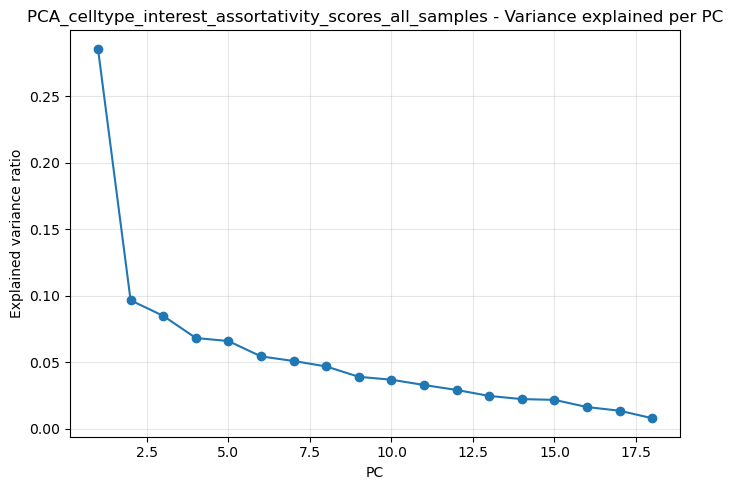

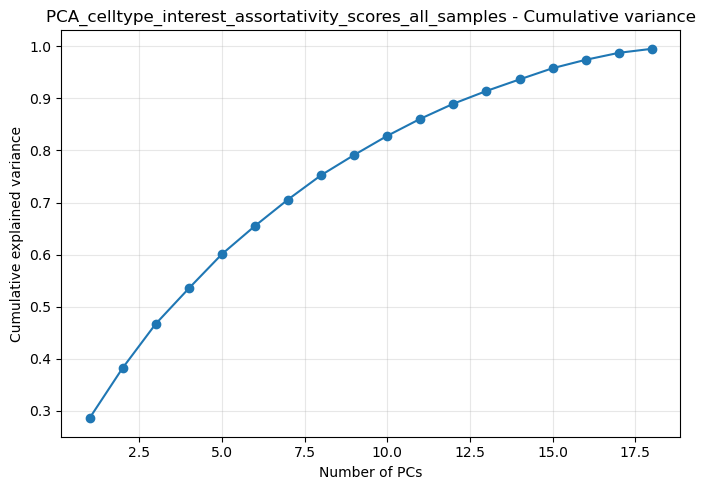

In [309]:
plot_pca_variance(
    adata_assort,
    plot_type="both",
    title_prefix=f"PCA_celltype_interest_assortativity_scores_all_samples",
    save_path=plot_save_dir,
    figsize=(7,5),
    dpi=300,
    show_plot = True,
    
)

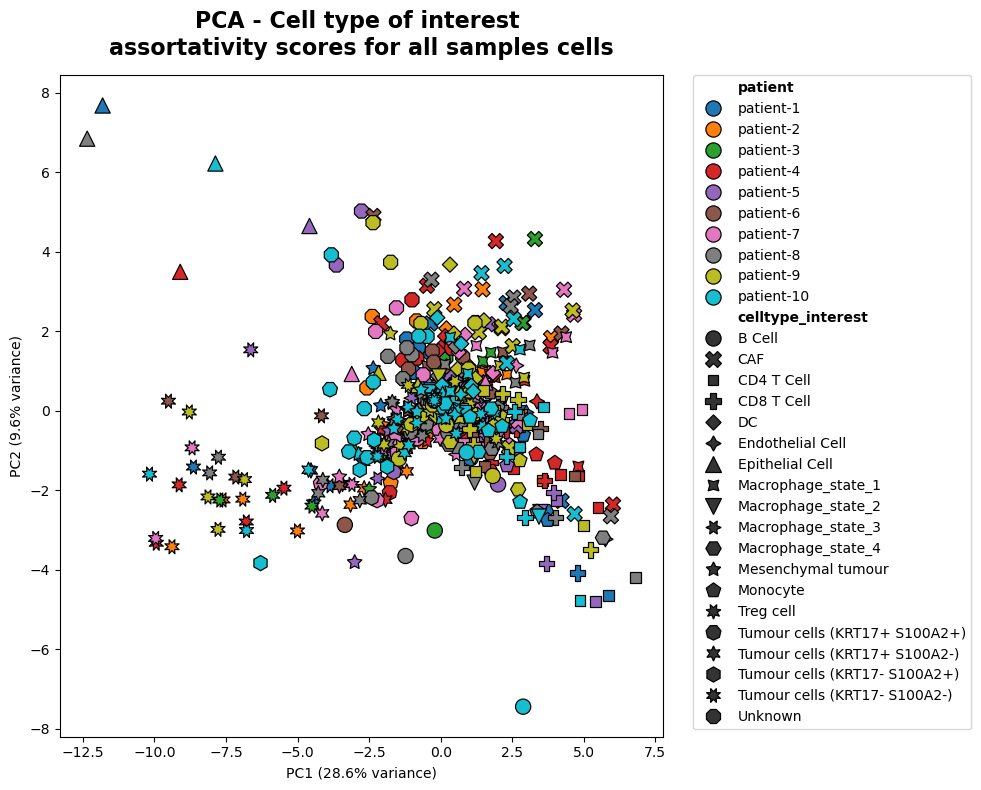

In [310]:
import seaborn as sns
import matplotlib.pyplot as plt

coords = pd.DataFrame(
    adata_assort.obsm["X_pca"][:, :2],
    columns=["PC1","PC2"],
    index=adata_assort.obs_names
)

coords = pd.concat(
    [coords, adata_assort.obs],
    axis=1
)

# variance expliquée
var_exp = adata_assort.uns["pca"]["variance_ratio"]

pc1_var = var_exp[0] * 100
pc2_var = var_exp[1] * 100


plt.figure(figsize=(10,8))

ax = sns.scatterplot(
    data=coords,
    x="PC1",
    y="PC2",
    hue="patient",
    style="celltype_interest",
    s=120,
    edgecolor="black"
)

# Ajouter variance sur les axes
ax.set_xlabel(f"PC1 ({pc1_var:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pc2_var:.1f}% variance)")


# déplacer la légende à droite
leg = ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0
)

# titres de sections en gras
for t in leg.get_texts():
    if t.get_text() in ["patient", "celltype_interest"]:
        t.set_fontweight("bold")

ax.set_title(
    "PCA - Cell type of interest \nassortativity scores for all samples cells",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.savefig(plot_save_dir/
    f"PCA_{marker}_celltype_interest_assortativity_scores_all_samples.png",
    dpi=300,
    bbox_inches="tight"
)
        
plt.tight_layout()
plt.show()

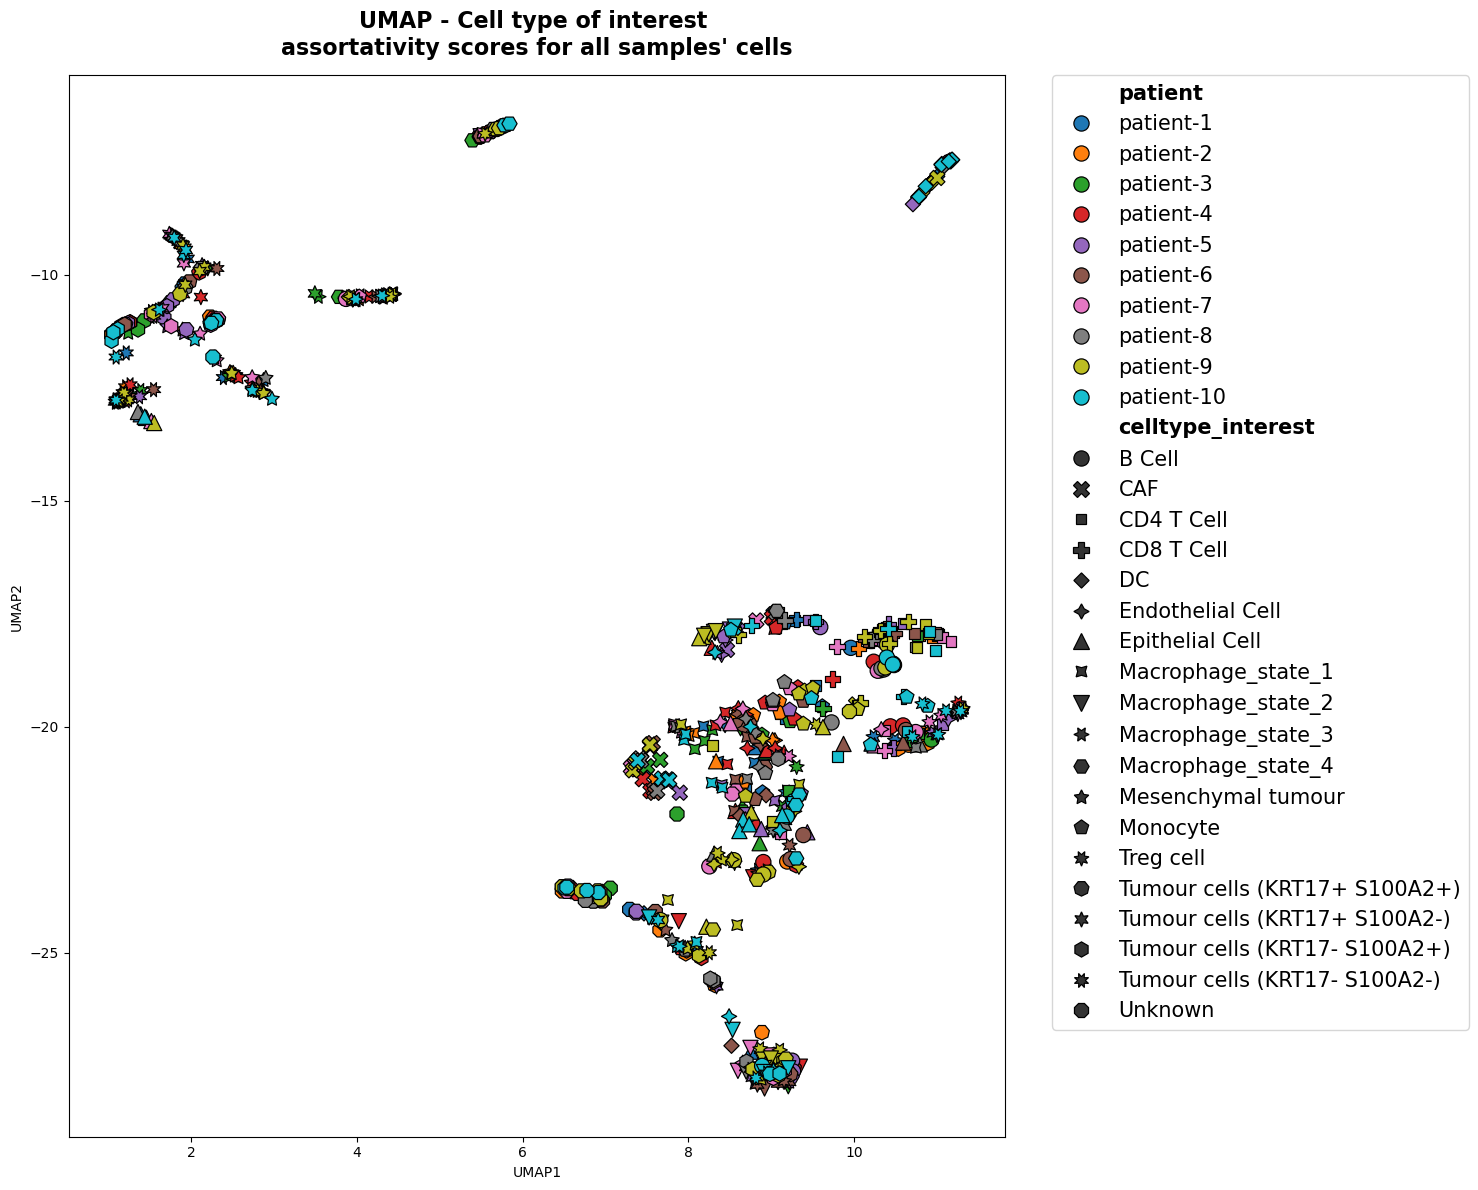

In [311]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

umap = pd.DataFrame(
    adata_assort.obsm["X_umap"],
    columns=["UMAP1", "UMAP2"],
    index=adata_assort.obs_names
)

umap = pd.concat([umap, adata_assort.obs], axis=1)

if all : 
    figsize = [15,12]
else :
    figsize = [10,7]

plt.figure(figsize= figsize)

ax = sns.scatterplot(
    data=umap,
    x="UMAP1",
    y="UMAP2",
    hue="patient",
    style="celltype_interest",
    s=120,
    edgecolor="black"
)

# déplacer la légende à droite
leg = ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize = 15
)

# titres de sections en gras
for t in leg.get_texts():
    if t.get_text() in ["patient", "celltype_interest"]:
        t.set_fontweight("bold")

ax.set_title(
    "UMAP - Cell type of interest \nassortativity scores for all samples' cells",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()


plt.savefig(plot_save_dir/
    f"UMAP_{marker}_celltype_interest_assortativity_scores_all_samples.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

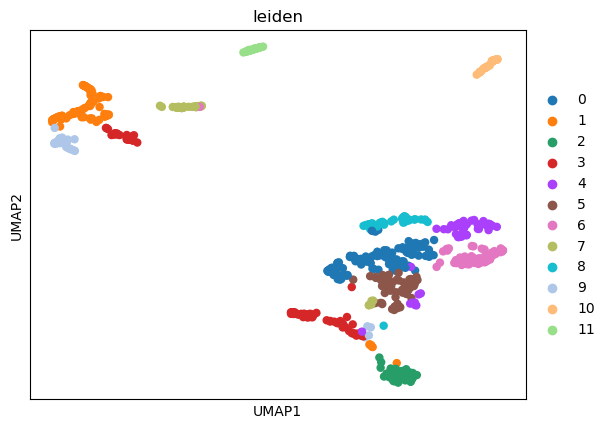

In [312]:
sc.pl.umap(
    adata_assort,
    color=["leiden"]
)


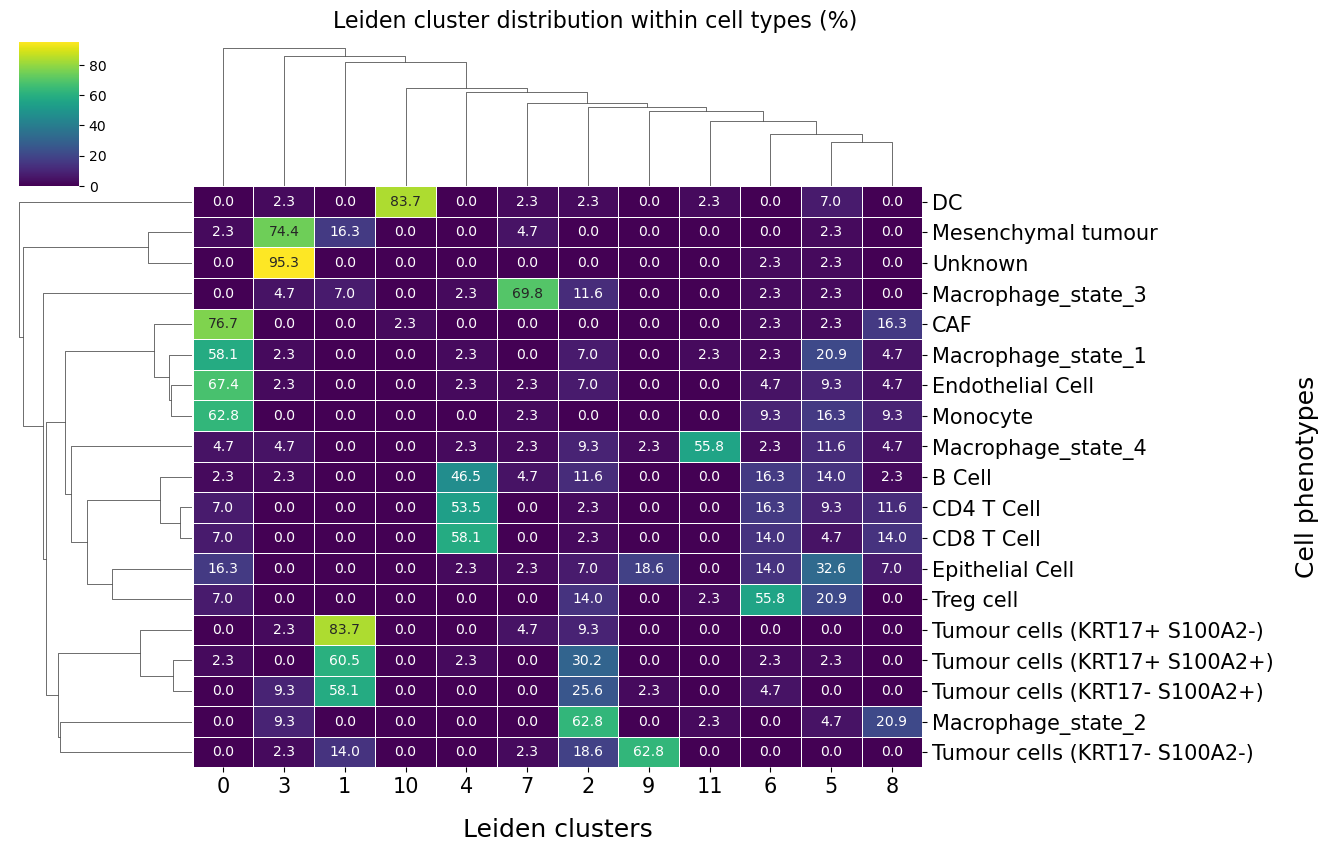

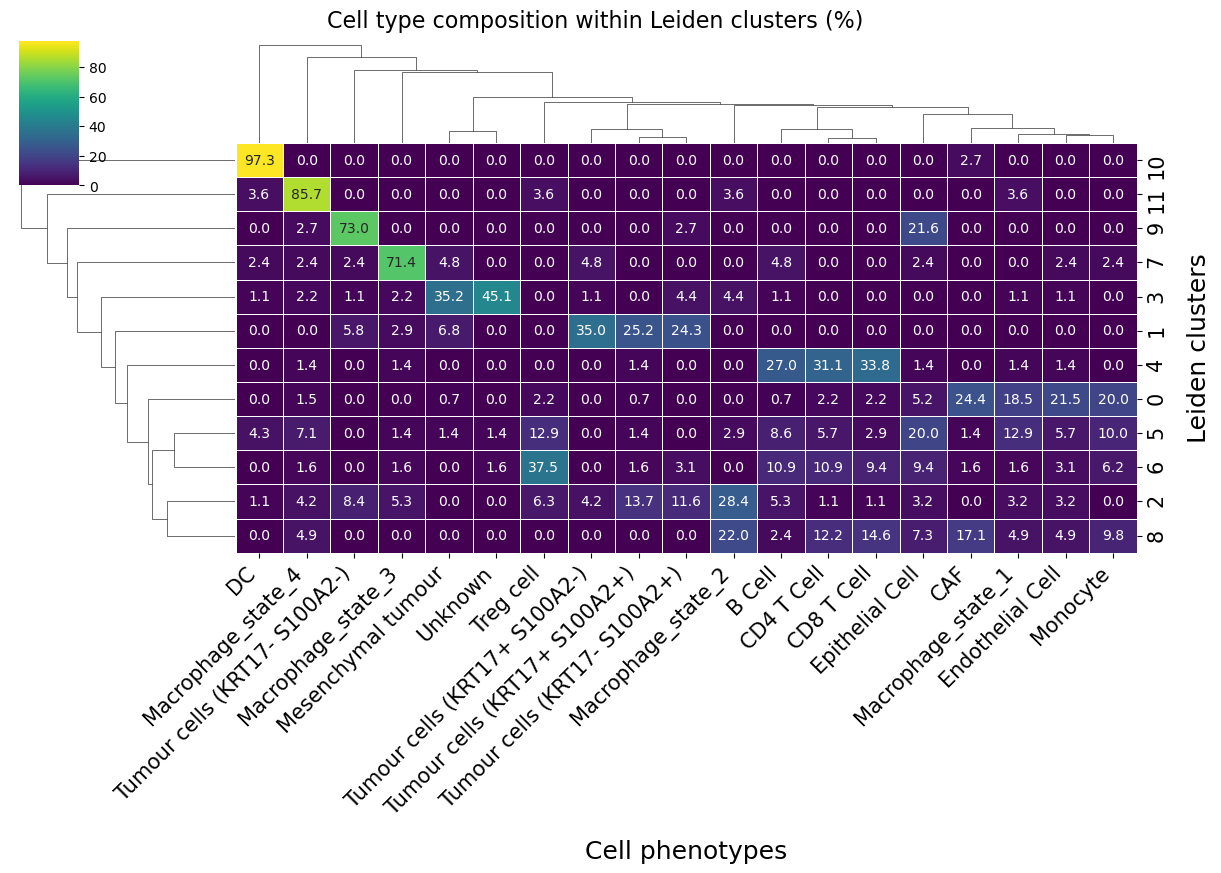

In [313]:
import seaborn as sns
import matplotlib.pyplot as plt
# ==========================================================
# Composition cellulaire par cluster Leiden
# ==========================================================

composition = (
    pd.crosstab(
        adata_assort.obs["celltype_interest"],
        adata_assort.obs["leiden"],
        
        normalize="index"
    )
    * 100
)


g = sns.clustermap(
    composition,
    cmap="viridis",
    row_cluster=True,
    col_cluster=True,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    figsize=(12,8)
)
g.ax_heatmap.tick_params(axis="x", labelsize=15)
g.ax_heatmap.tick_params(axis="y", labelsize=15)

g.ax_heatmap.set_ylabel("Cell phenotypes", fontsize=18, labelpad=15)
g.ax_heatmap.set_xlabel("Leiden clusters", fontsize=18, labelpad=15)

# Titre
g.fig.suptitle(
    "Leiden cluster distribution within cell types (%)",
    fontsize=16,
    y=1.02
)


# Sauvegarde
g.fig.savefig(plot_save_dir/
    "leiden_distribution_across_celltypes.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# ==========================================================
# Composition cellulaire par cluster Leiden
# ==========================================================

composition = (
    pd.crosstab(
        adata_assort.obs["leiden"],
        adata_assort.obs["celltype_interest"],

        
        normalize="index"
    )
    * 100
)

g = sns.clustermap(
    composition,
    cmap="viridis",
    row_cluster=True,
    col_cluster=True,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    figsize=(12,8)
)
g.ax_heatmap.tick_params(axis="x", labelsize=15)
g.ax_heatmap.tick_params(axis="y", labelsize=15)

g.ax_heatmap.set_xlabel("Cell phenotypes", fontsize=18, labelpad=15)
g.ax_heatmap.set_ylabel("Leiden clusters", fontsize=18, labelpad=15)


# Rotation des labels de l'axe x
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right"
) 
# Titre
g.fig.suptitle(
    "Cell type composition within Leiden clusters (%)",
    fontsize=16,
    y=1.02
)


# Sauvegarde
g.fig.savefig(plot_save_dir/
    "celltype_composition_across_leiden_clusters.png",
    dpi=300,
    bbox_inches="tight"
)




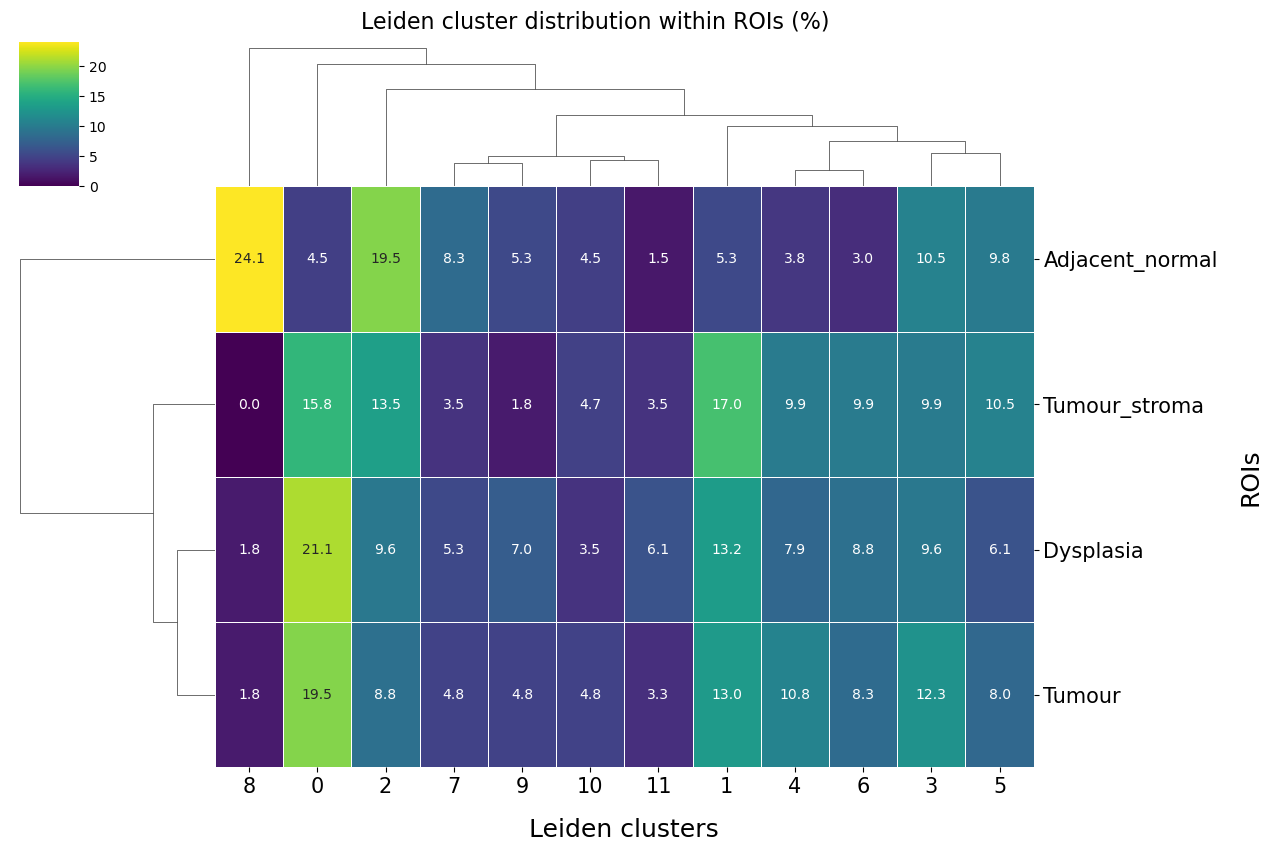

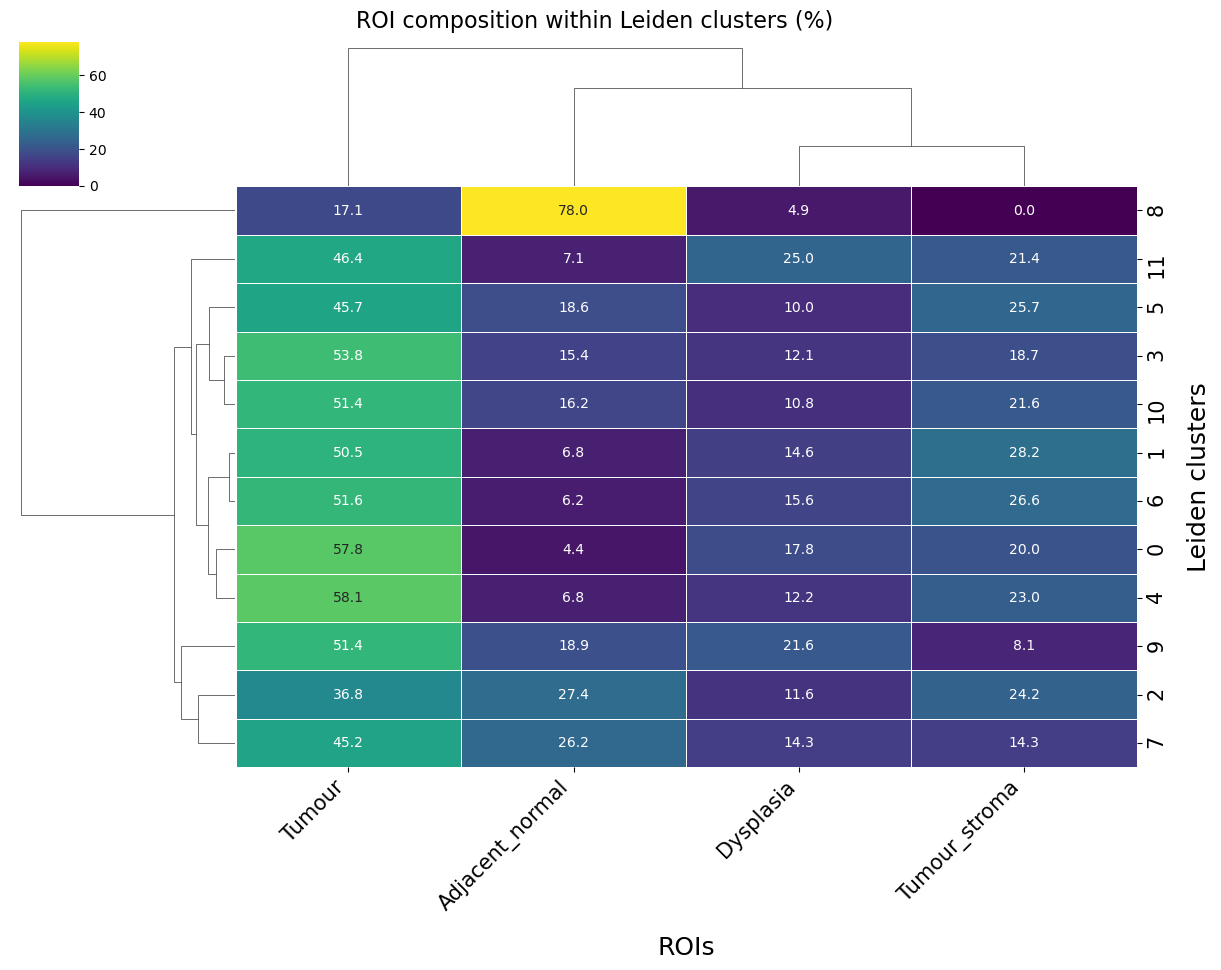

In [314]:
import seaborn as sns
import matplotlib.pyplot as plt
# ==========================================================
# Composition cellulaire par cluster Leiden
# ==========================================================

composition = (
    pd.crosstab(
        adata_assort.obs["region_grouped"],
        adata_assort.obs["leiden"],
        
        normalize="index"
    )
    * 100
)


g = sns.clustermap(
    composition,
    cmap="viridis",
    row_cluster=True,
    col_cluster=True,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    figsize=(12,8)
)
g.ax_heatmap.tick_params(axis="x", labelsize=15)
g.ax_heatmap.tick_params(axis="y", labelsize=15)

g.ax_heatmap.set_ylabel("ROIs", fontsize=18, labelpad=15)
g.ax_heatmap.set_xlabel("Leiden clusters", fontsize=18, labelpad=15)


# Rotation des labels de l'axe x
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(),
    rotation=0,
    ha="left"
) 


# Titre
g.fig.suptitle(
    "Leiden cluster distribution within ROIs (%)",
    fontsize=16,
    y=1.02
)


# Sauvegarde
g.fig.savefig(plot_save_dir/
    "leiden_distribution_across_ROIs.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# ==========================================================
# Composition cellulaire par cluster Leiden
# ==========================================================

composition = (
    pd.crosstab(
        adata_assort.obs["leiden"],
        adata_assort.obs["region_grouped"],

        
        normalize="index"
    )
    * 100
)

g = sns.clustermap(
    composition,
    cmap="viridis",
    row_cluster=True,
    col_cluster=True,
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    figsize=(12,8)
)
g.ax_heatmap.tick_params(axis="x", labelsize=15)
g.ax_heatmap.tick_params(axis="y", labelsize=15)

g.ax_heatmap.set_xlabel("ROIs", fontsize=18, labelpad=15)
g.ax_heatmap.set_ylabel("Leiden clusters", fontsize=18, labelpad=15)


# Rotation des labels de l'axe x
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right"
) 
# Titre
g.fig.suptitle(
    "ROI composition within Leiden clusters (%)",
    fontsize=16,
    y=1.02
)


# Sauvegarde
g.fig.savefig(plot_save_dir/
    "ROI_composition_across_leiden_clusters.png",
    dpi=300,
    bbox_inches="tight"
)




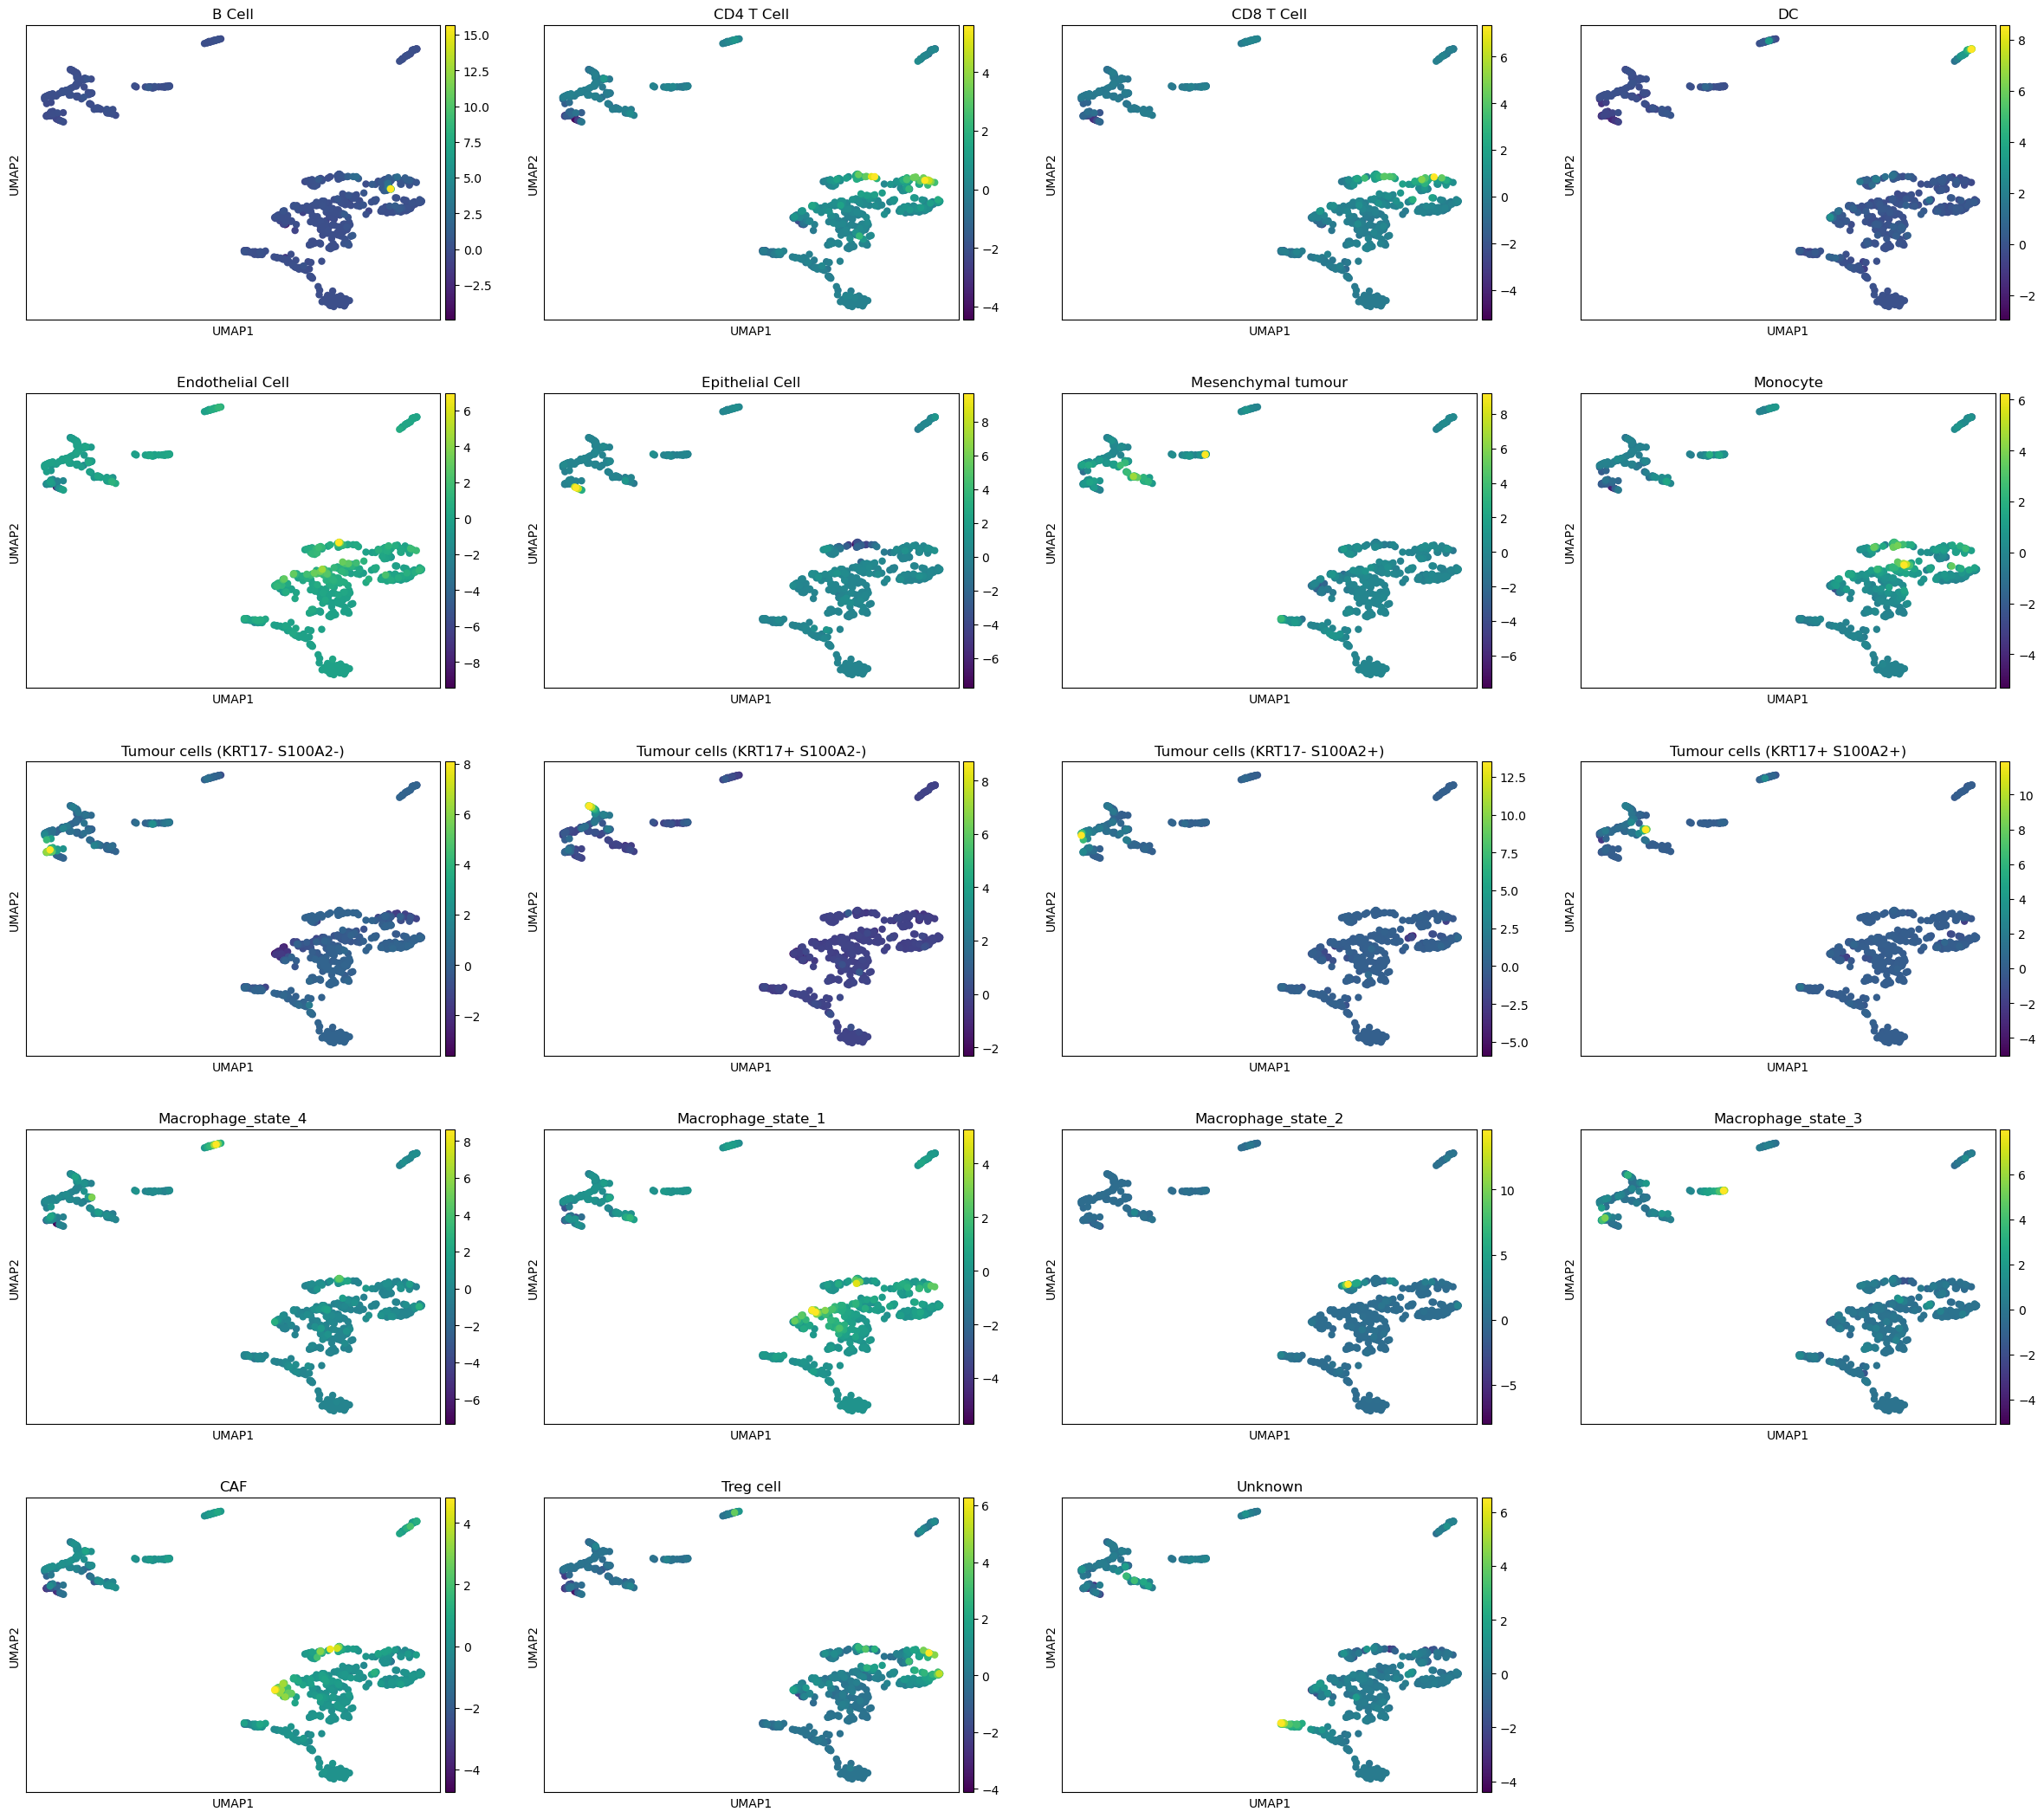

In [315]:
sc.pl.umap(
    adata_assort,
    color=celltypes_interest
)



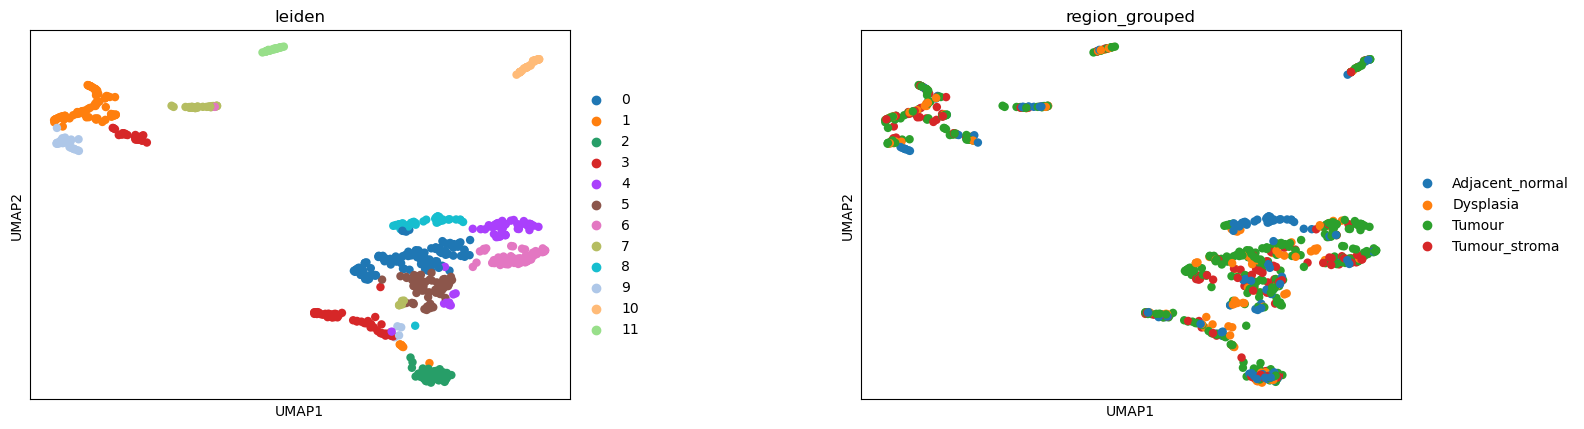

In [316]:


import matplotlib.pyplot as plt

sc.pl.umap(
    adata_assort,
    color=[
        "leiden",
        "region_grouped"
    ],
    wspace=0.4,
    show=False
)

plt.savefig(plot_save_dir/
    "UMAP_leiden_region_grouped.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

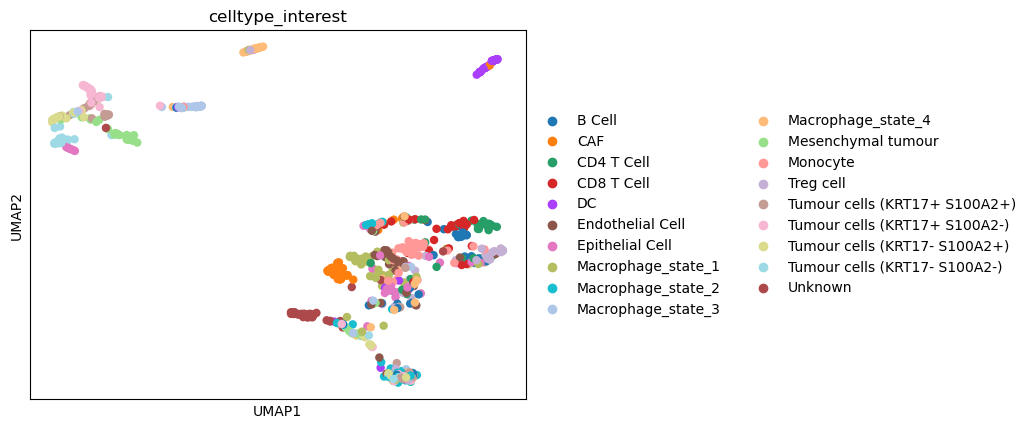

In [317]:
sc.pl.umap(
    adata_assort,
    color=["celltype_interest",
     
    ],
    wspace=0.4
)

In [318]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    adata_assort.obs["celltype_interest"],
    adata_assort.obs["leiden"]
)

nmi = normalized_mutual_info_score(
    adata_assort.obs["celltype_interest"],
    adata_assort.obs["leiden"]
)

print(ari, nmi)

0.26461285134769336 0.48038427809249934


In [319]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

threshold = threshold

# Table des flux
df = (
    adata_assort.obs
    .groupby(["celltype_interest", "leiden"], observed=True)
    .size()
    .reset_index(name="count")
)

# Conserver uniquement les flux >= threshold
df = df[df["count"] >= threshold].copy()

# Conserver uniquement les cellules appartenant à ces flux
obs_keep = adata_assort.obs.merge(
    df[["celltype_interest", "leiden"]],
    on=["celltype_interest", "leiden"],
    how="inner"
)

# Calcul ARI/NMI
ari = adjusted_rand_score(
    obs_keep["celltype_interest"],
    obs_keep["leiden"]
)

nmi = normalized_mutual_info_score(
    obs_keep["celltype_interest"],
    obs_keep["leiden"]
)

print(f"ARI = {ari:.3f}")
print(f"NMI = {nmi:.3f}")

# Export
pd.DataFrame({
    "Metric": ["ARI", "NMI"],
    "Value": [ari, nmi]
}).to_csv(
    os.path.join(plot_save_dir, "ARI_NMI_scores.csv"),
    index=False
)

ARI = 0.384
NMI = 0.674


In [320]:
def make_sankey(
    adata,
    source_col,
    target_col,
    title,
    threshold=1000, #nombre de cell minimum à avoir dans un flux pour l'afficher
    save_dir=None,
    show=False,
    export_csv=False
):

    def color_to_rgba(color, alpha=0.35):
        if color.startswith("#"):
            color = color.lstrip("#")
            r = int(color[0:2], 16)
            g = int(color[2:4], 16)
            b = int(color[4:6], 16)
            
        elif color.startswith("rgb"):
            rgb = color.replace("rgb(", "").replace(")", "")
            r, g, b = map(int, rgb.split(","))
            
        else:
            raise ValueError(f"Format couleur non reconnu: {color}")
        
        return f"rgba({r},{g},{b},{alpha})"

    # table flux
    df = (
        adata.obs
        .groupby([source_col, target_col], observed=True)
        .size()
        .reset_index(name="count")
    )

    df = df[df["count"] >= threshold].copy()


    # noeuds
    labels = list(
        pd.concat([
            df[source_col],
            df[target_col]
        ]).unique()
    )

    label_to_index = {
        label: i for i, label in enumerate(labels)
    }


    # liens
    source = df[source_col].map(label_to_index)
    target = df[target_col].map(label_to_index)
    value = df["count"]


        # ==========================
    # Palettes couleurs
    # ==========================

    def get_palette(column, categories):
        

        # catégories AnnData
        if hasattr(adata.obs[column], "cat"):
            obs_categories = adata.obs[column].cat.categories
        else:
            obs_categories = adata.obs[column].unique()


        # Couleurs Scanpy pour Leiden
        if column == "leiden_clean" and "leiden_colors" in adata.uns:
            return dict(
                zip(
                    obs_categories,
                    adata.uns["leiden_colors"]
                )
            )


        # Couleurs Scanpy pour State
        elif column == "state" and "state_colors" in adata.uns:
            return dict(
                zip(
                    obs_categories,
                    adata.uns["state_colors"]
                )
            )


        # Palette automatique
        else:
            colors = px.colors.qualitative.Set2
            return {
                x: colors[i % len(colors)]
                for i, x in enumerate(categories)
            }


    source_categories = df[source_col].unique()
    target_categories = df[target_col].unique()


    source_palette = get_palette(
        source_col,
        source_categories
    )

    target_palette = get_palette(
        target_col,
        target_categories
    )


    palette = {
        **source_palette,
        **target_palette
    }


    node_colors = [
        palette.get(x, "#BDBDBD")
        for x in labels
    ]


    # liens colorés selon la source
    link_colors = [
        color_to_rgba(
            source_palette[x],
            alpha=0.35
        )
        for x in df[source_col]
    ]

    #####
    df["source_total"] = (
    df.groupby(source_col)["count"]
    .transform("sum")
    )

    df["source_percent"] = (
        df["count"] / df["source_total"] * 100
    )

    customdata=df["source_percent"]



    df["target_total"] = (
    df.groupby(target_col)["count"]
    .transform("sum")
    )

    df["target_percent"] = (
        df["count"] / df["target_total"] * 100
    )




    node_sizes = (
    adata.obs[source_col]
    .value_counts()
    .to_dict()
    )

    node_sizes.update(
        adata.obs[target_col]
        .value_counts()
        .to_dict()
    )

    node_counts = [
        node_sizes[x]
        for x in labels
    ]


    purity = (
    df.groupby(source_col)["count"]
    .max()
    /
    df.groupby(source_col)["count"]
    .sum()
    )

    print(purity)



    global_target = (
    adata.obs[target_col]
    .value_counts(normalize=True)
    )

    df["enrichment"] = (
        (df["count"] / df["source_total"])
        /
        df[target_col].map(global_target)
    )


    # figure
    fig = go.Figure(
        go.Sankey(
            arrangement="snap",

            node=dict(
                pad=30,
                thickness=30,
                line=dict(
                    color="black",
                    width=0.5
                ),
                label=labels,
                color=node_colors,
                customdata=node_counts,
                hovertemplate=(
                    "<b>%{label}</b>"
                    "<br>%{customdata} cellules"
                    "<extra></extra>"
                )
            ),

            link=dict(
                source=source,
                target=target,
                value=value,
                customdata=np.stack(
                    [
                        df["source_percent"],
                        df["target_percent"],
                        df["enrichment"]
                    ],
                    axis=-1
                ),
                color=link_colors,

                hovertemplate=(
                    "%{source.label} → %{target.label}"
                    "<br><b>%{value}</b> cellules"
                    "<br>%{customdata[0]:.1f}% du cluster source"
                    "<br>%{customdata[1]:.1f}% de la niche"
                    "<br>Enrichissement: %{customdata[2]:.2f}"
                    "<extra></extra>"
                    )
                )
            )
        )
    


    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=22)
        ),
        font=dict(
            size=15,
            family="Arial"
        ),
        width=1000,
        height=800,
        paper_bgcolor="white"
    )


        # ==========================
    # Sauvegarde
    # ==========================

    if save_dir is not None:
        import os
        import re

        os.makedirs(save_dir, exist_ok=True)

        # nom de fichier propre à partir du titre
        filename = re.sub(
            r"[^a-zA-Z0-9]+",
            "_",
            title
        ).strip("_")

        html_path = os.path.join(
            save_dir,
            filename + ".html"
        )

        png_path = os.path.join(
            save_dir,
            filename + ".png"
        )

        fig.write_html(html_path)

        try:
            fig.write_image(
                png_path,
                scale=3
            )
        except:
            print(
                "PNG non sauvegardé : installe kaleido avec 'pip install kaleido'"
            )
            # Export des pourcentages
        if export_csv:
            csv_path = os.path.join(
                save_dir,
                filename + "_percentages.csv"
            )

            df_export = df[
                [
                    source_col,
                    target_col,
                    "count",
                    "source_total",
                    "source_percent",
                    "target_total",
                    "target_percent",
                    "enrichment"
                ]
            ].copy()

            df_export.to_csv(
                csv_path,
                index=False
            )
    # ==========================
    # Affichage
    # ==========================

    if show:
        fig.show()


    return fig, df_export

In [321]:
'''''
mapping = {
    'Tumour cells (KRT17+ S100A2+)' : "Positive for at least one marker",
    'Tumour cells (KRT17+ S100A2-)' : "Positive for at least one marker",
    'Tumour cells (KRT17- S100A2+)' :"Positive for at least one marker",
    'Tumour cells (KRT17- S100A2-)' : "Double negative"

}
adata_assort.obs["grouped_phenotypes"].unique()
adata_assort.obs["grouped_phenotypes"] = adata_assort.obs["celltype_interest"].map(mapping)
adata_assort.obs["grouped_phenotypes"] = adata_assort.obs["grouped_phenotypes"].astype(str)
'''''

'\'\'\nmapping = {\n    \'Tumour cells (KRT17+ S100A2+)\' : "Positive for at least one marker",\n    \'Tumour cells (KRT17+ S100A2-)\' : "Positive for at least one marker",\n    \'Tumour cells (KRT17- S100A2+)\' :"Positive for at least one marker",\n    \'Tumour cells (KRT17- S100A2-)\' : "Double negative"\n\n}\nadata_assort.obs["grouped_phenotypes"].unique()\nadata_assort.obs["grouped_phenotypes"] = adata_assort.obs["celltype_interest"].map(mapping)\nadata_assort.obs["grouped_phenotypes"] = adata_assort.obs["grouped_phenotypes"].astype(str)\n'

In [322]:
save_dir = plot_save_dir

import plotly.express as px
import plotly.graph_objects as go
adata_assort.obs["celltype_interest"] = adata_assort.obs["celltype_interest"].astype(str)
adata_assort.obs["leiden"] = adata_assort.obs["leiden"].astype(str)
fig_group_leiden,df1 = make_sankey(
    adata_assort,
    "celltype_interest",
    "leiden",
    "Phenotypes → Assortativity Clusters",
    save_dir=save_dir,
    show= True,
    threshold = threshold,
    export_csv=True,
)


celltype_interest
B Cell                           0.526316
CAF                              0.825000
CD4 T Cell                       0.657143
CD8 T Cell                       0.675676
DC                               1.000000
Endothelial Cell                 1.000000
Epithelial Cell                  0.400000
Macrophage_state_1               0.735294
Macrophage_state_2               0.750000
Macrophage_state_3               0.857143
Macrophage_state_4               0.827586
Mesenchymal tumour               0.820513
Monocyte                         0.794118
Treg cell                        0.615385
Tumour cells (KRT17+ S100A2+)    0.666667
Tumour cells (KRT17+ S100A2-)    1.000000
Tumour cells (KRT17- S100A2+)    0.694444
Tumour cells (KRT17- S100A2-)    0.658537
Unknown                          1.000000
Name: count, dtype: float64


## Suite Analyse statistiques

### Paramètres

In [346]:
plot_save_dir = Path("OUTPUT_arcsinh/states/corrected_double_status_tumour_and_macrostates_labeled/niche_states/assortativity/500_shuffles")
# =====================================================
# Cell types d'intérêt
# =====================================================
celltype = "tumor_cells" # macrophages_states ou tumor_cells

if celltype == "tumor_cells": 
    celltypes_interest = [
                    "Tumour cells (KRT17- S100A2-)",   # Double negative
                    "Tumour cells (KRT17+ S100A2-)",
                    "Tumour cells (KRT17- S100A2+)",
                    "Tumour cells (KRT17+ S100A2+)", # Double positive

        #"Mesenchymal tumour"  

    ]
    imune_partners = [
                "B Cell",
                "CD4 T Cell",
                "CD8 T Cell",
                "DC",
                #"Endothelial Cell",
                #"Epithelial Cell",
                #"Mesenchymal tumour",
                "Monocyte",
                "CAF",
                "Treg cell",
                #"Unknown",
                "Macrophage_state_4",
                "Macrophage_state_1",
                "Macrophage_state_2",
                "Macrophage_state_3",

]

if celltype == "macrophages_states": 
    celltypes_interest = [
                "Macrophage_state_4",
                "Macrophage_state_1",
                "Macrophage_state_2",
                "Macrophage_state_3",


        #"Mesenchymal tumour"  

    ]
    imune_partners = [
                "B Cell",
                "CD4 T Cell",
                "CD8 T Cell",
                "DC",
                #"Endothelial Cell",
                #"Epithelial Cell",
                #"Mesenchymal tumour",
                "Monocyte",
                "CAF",
                "Treg cell",
                #"Unknown",
                "Tumour cells (KRT17- S100A2-)",   # Double negative
                "Tumour cells (KRT17+ S100A2-)",
                "Tumour cells (KRT17- S100A2+)",
                "Tumour cells (KRT17+ S100A2+)", # Double positive

]    



### Fonctions

In [347]:
#Fonction qui fait les comparaisons statistiques
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

from itertools import combinations
from patsy import dmatrix
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests


def compare_assortativity_mixed(
    df,
    assortativity_col,
    tumor_col,
    partner_col,
    patient_col,
    correction="fdr_bh",
):

    df = df.copy()

    df = df.dropna(
        subset=[
            assortativity_col,
            tumor_col,
            partner_col,
            patient_col,
        ]
    )

    df[tumor_col] = df[tumor_col].astype("category")
    df[partner_col] = df[partner_col].astype("category")

    formula = (
        f"{assortativity_col} ~ "
        f"C({tumor_col}) * C({partner_col})"
    )

    model = smf.mixedlm(
        formula,
        data=df,
        groups=df[patient_col],
    )

    fit = model.fit(reml=False)

    print(fit.summary())

    beta = fit.fe_params
    cov = fit.cov_params().loc[beta.index, beta.index]

    tumor_levels = df[tumor_col].cat.categories
    partner_levels = df[partner_col].cat.categories

    results = []

    for partner in partner_levels:

        for t1, t2 in combinations(tumor_levels, 2):

            new = pd.DataFrame({
                tumor_col: [t1, t2],
                partner_col: [partner, partner]
            })

            X = dmatrix(
                fit.model.data.design_info,
                new,
                return_type="dataframe",
            )

            X = X[beta.index]

            L = X.iloc[0] - X.iloc[1]

            estimate = float(L @ beta)

            se = np.sqrt(float(L @ cov @ L))

            z = estimate / se

            p = 2 * norm.sf(abs(z))

            results.append(
                {
                    "immune_partner": partner,
                    "comparison": f"{t1} vs {t2}",
                    "estimate": estimate,
                    "SE": se,
                    "z": z,
                    "pvalue": p,
                }
            )

    results = pd.DataFrame(results)

    results["padj"] = multipletests(
        results["pvalue"],
        method=correction,
    )[1]

    results["significant"] = results["padj"] < 0.05

    return fit, results

In [348]:
# fonction plot assortativity heatmap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def plot_assortativity_heatmap(results, partner, figsize=(8, 6)):
    """
    Heatmap des différences d'assortativité (estimate)
    pour un partenaire immunitaire donné.
    """

    # Filtrer le partenaire immunitaire
    data = results[
        results["immune_partner"] == partner
    ].copy()

    # Extraire les deux tumeurs de la comparaison
    data[["tumor1", "tumor2"]] = data["comparison"].str.split(
        " vs ",
        expand=True
    )

    # Liste de toutes les tumeurs
    tumors = sorted(
        set(data["tumor1"]).union(set(data["tumor2"]))
    )

    # Matrices vides
    heatmap = pd.DataFrame(
        np.nan,
        index=tumors,
        columns=tumors
    )

    annot = pd.DataFrame(
        "",
        index=tumors,
        columns=tumors
    )


    # Remplissage
    for _, row in data.iterrows():

        t1 = row["tumor1"]
        t2 = row["tumor2"]

        estimate = row["estimate"]
        padj = row["padj"]

        # étoiles
        if padj < 0.001:
            star = "***"
        elif padj < 0.01:
            star = "**"
        elif padj < 0.05:
            star = "*"
        else:
            star = ""

        # effet tumeur1 - tumeur2
        heatmap.loc[t1, t2] = estimate
        annot.loc[t1, t2] = (
            f"{estimate:.2f}{star}"
        )

        # symétrie inverse
        heatmap.loc[t2, t1] = -estimate
        annot.loc[t2, t1] = (
            f"{-estimate:.2f}{star}"
        )


    # Diagonale = 0
    np.fill_diagonal(
        heatmap.values,
        0
    )

    np.fill_diagonal(
        annot.values,
        "-"
    )


    # Plot
    plt.figure(figsize=figsize)

    ax = sns.heatmap(
        heatmap,
        annot=annot,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        square=True,
        annot_kws={
            "fontsize": 12
        },
        cbar_kws={
            "label": "Difference in adjusted mean assortativity z-scores"
        },
    )

    plt.title(
    f"Difference in adjusted mean assortativity z-scores - {partner}",
    fontsize=18,
    pad=15
    )

    plt.xlabel(
        "Phenotype",
        fontsize=16
    )

    plt.ylabel(
        "Phenotype",
        fontsize=16
    )

    plt.xticks(
        rotation=20,
        ha="right",
        fontsize=14
    )

    plt.yticks(
        rotation=0,
        fontsize=14
    )

        # Taille du label de la colorbar
    cbar = ax.collections[0].colorbar
    cbar.set_label(
        "Δ mean assortativity z-score (Y − X)",
        fontsize=14
    )
    cbar.ax.tick_params(
        labelsize=12
    )

 
    
    plt.tight_layout()

       

    return heatmap
    

### Données

In [349]:
#Récupérations d'un dataframe stats_df qui met les données dans bonne forme pour analyse stats qui suit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches

from matplotlib.colors import SymLogNorm, ListedColormap
from matplotlib.gridspec import GridSpec


# =====================================================
# Préparer les données
# =====================================================

net_stat_indexed = net_stat.set_index("id").copy()
#net_stat_indexed = net_stat_indexed[
#    net_stat_indexed["region_grouped"] != "Adjacent_normal"
#]


assort_cols = [
    col for col in net_stat_indexed.columns
    if col.endswith(" Z") and col != "assort Z"
]



# =====================================================
# Trier les samples
# =====================================================

def sort_samples(columns):

    def extract_order(x):

        parts = x.split("_")

        patient = int(
            parts[0].replace("patient-", "")
        )

        sample = int(
            parts[1].replace("sample-", "")
        )

        return patient, sample


    return sorted(
        columns,
        key=extract_order
    )



# =====================================================
# Extraction assortativité
# =====================================================

def get_assort_for_celltype_interest(celltype_interest):

    result = pd.DataFrame()


    for sample in net_stat_indexed.index:


        assort_values = (
            net_stat_indexed
            .loc[sample, assort_cols]
            .astype(float)
        )


        values = {}


        for pair, score in assort_values.items():


            pair_clean = pair.replace(" Z", "")


            if celltype_interest not in pair_clean:
                continue



            other = (
                pair_clean
                .replace(celltype_interest, "")
                .replace(" - ", "")
                .strip()
            )


            if other == "":
                continue


            values[other] = score



        result = pd.concat(
            [
                result,
                pd.Series(
                    values,
                    name=sample
                )
            ],
            axis=1
        )


    result.index.name = "Cell type"
    result.columns.name = "Patient"


    return result



# =====================================================
# Couleurs patients
# =====================================================

def patient_annotation(samples):


    patient_series = pd.Series(
        samples.str.split("_").str[0],
        index=samples
    )


    unique_patients = sorted(
        patient_series.unique(),
        key=lambda x: int(x.split("-")[-1])
    )


    palette = sns.color_palette(
        "tab20",
        len(unique_patients)
    )


    patient_to_color = dict(
        zip(unique_patients, palette)
    )


    patient_int = np.array(
        [
            unique_patients.index(p)
            for p in patient_series
        ]
    )


    cmap = ListedColormap(
        [
            patient_to_color[p]
            for p in unique_patients
        ]
    )


    return (
        patient_int,
        cmap,
        patient_to_color,
        unique_patients
    )



# =====================================================
# Couleurs localisation
# =====================================================

def location_annotation(samples):


    location_series = (
        net_stat_indexed
        .loc[samples, "region_grouped"]
    )


    unique_locations = (
        location_series
        .dropna()
        .unique()
    )


    palette = sns.color_palette(
        "Set3",
        len(unique_locations)
    )


    location_to_color = dict(
        zip(unique_locations, palette)
    )


    location_int = np.array(
        [
            list(unique_locations).index(x)
            for x in location_series
        ]
    )


    cmap = ListedColormap(
        [
            location_to_color[x]
            for x in unique_locations
        ]
    )


    return (
        location_int,
        cmap,
        location_to_color,
        unique_locations
    )






records = []

for ct in celltypes_interest:

    df = get_assort_for_celltype_interest(ct).T

    for immune in imune_partners:

        if immune not in df.columns:
            continue

        tmp = pd.DataFrame({
            "sample": df.index,
            "region_grouped": net_stat_indexed.loc[df.index, "region_grouped"].values,
            "celltype_interest": ct,
            "immune_partner": immune,
            "assortativity": df[immune].values
        })
        tmp["patient"] = (
            tmp["sample"]
            .str.extract(r"patient-(\d+)")
            .astype(int)
        )
        records.append(tmp)

stats_df = pd.concat(records, ignore_index=True)

### Comparaisons statistiques

In [350]:
stats_df

,sample,region_grouped,celltype_interest,immune_partner,assortativity,patient
0,patient-4_sample-1,Tumour,Tumour cells (KRT17- S100A2-),B Cell,-5.680985,4
1,patient-9_sample-4,Dysplasia,Tumour cells (KRT17- S100A2-),B Cell,-1.096951,9
2,patient-4_sample-5,Adjacent_normal,Tumour cells (KRT17- S100A2-),B Cell,NaN,4
3,patient-1_sample-4,Adjacent_normal,Tumour cells (KRT17- S100A2-),B Cell,NaN,1
4,patient-8_sample-2,Tumour,Tumour cells (KRT17- S100A2-),B Cell,-4.432916,8
...,...,...,...,...,...,...
1887,patient-9_sample-6,Adjacent_normal,Tumour cells (KRT17+ S100A2+),Macrophage_state_3,NaN,9
1888,patient-2_sample-4,Tumour_stroma,Tumour cells (KRT17+ S100A2+),Macrophage_state_3,-0.175863,2
1889,patient-10_sample-1,Tumour,Tumour cells (KRT17+ S100A2+),Macrophage_state_3,NaN,10
1890,patient-8_sample-1,Tumour,Tumour cells (KRT17+ S100A2+),Macrophage_state_3,5.663446,8


In [351]:
# je fais les comparaisons statistiques
models, results = compare_assortativity_mixed(
    df = stats_df,
    assortativity_col = "assortativity",
    tumor_col = "celltype_interest",
    partner_col = "immune_partner",
    patient_col = "patient",
)

                                                   Mixed Linear Model Regression Results
Model:                                       MixedLM                            Dependent Variable:                            assortativity
No. Observations:                            1338                               Method:                                        ML           
No. Groups:                                  10                                 Scale:                                         53.6893      
Min. group size:                             97                                 Log-Likelihood:                                -4568.5028   
Max. group size:                             161                                Converged:                                     Yes          
Mean group size:                             133.8                                                                                          
-----------------------------------------------------------------

In [352]:
# j'enrigistre les comparaisons statistiques
save_dir_results = Path(plot_save_dir) / f"comparaisons/{celltype}" 
save_dir_results.mkdir(parents= True, exist_ok=True)

results.to_csv(save_dir_results/
    "results_pvalues.csv",
    index=False
)

### Visualisations des comparaisons statistiques

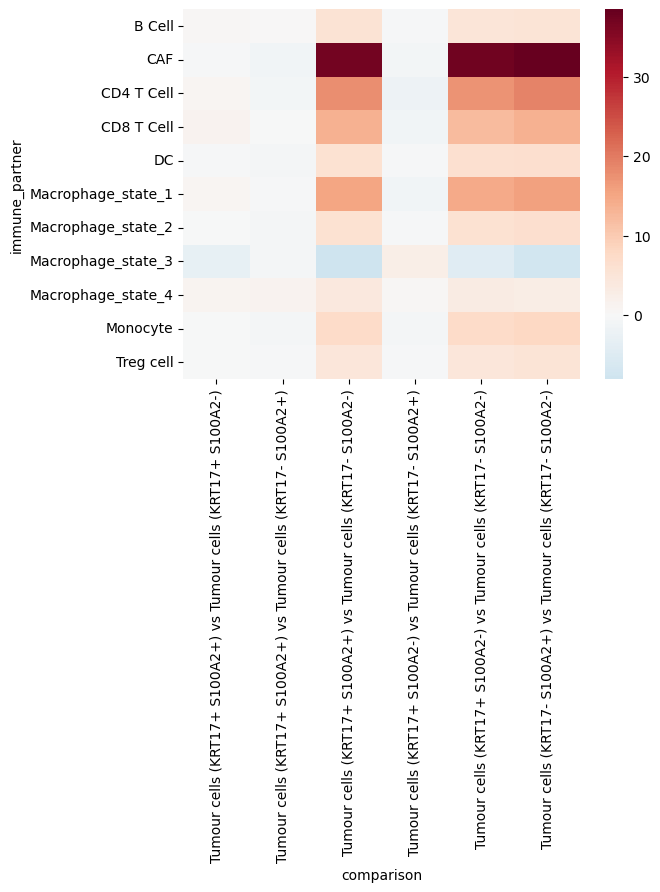

In [353]:
heat = results.pivot_table(
    index="immune_partner",
    columns="comparison",
    values="estimate"
)

sns.heatmap(
    heat,
    center=0,
    cmap="RdBu_r"
)
plt.show()

<Axes: xlabel='comparison', ylabel='immune_partner'>

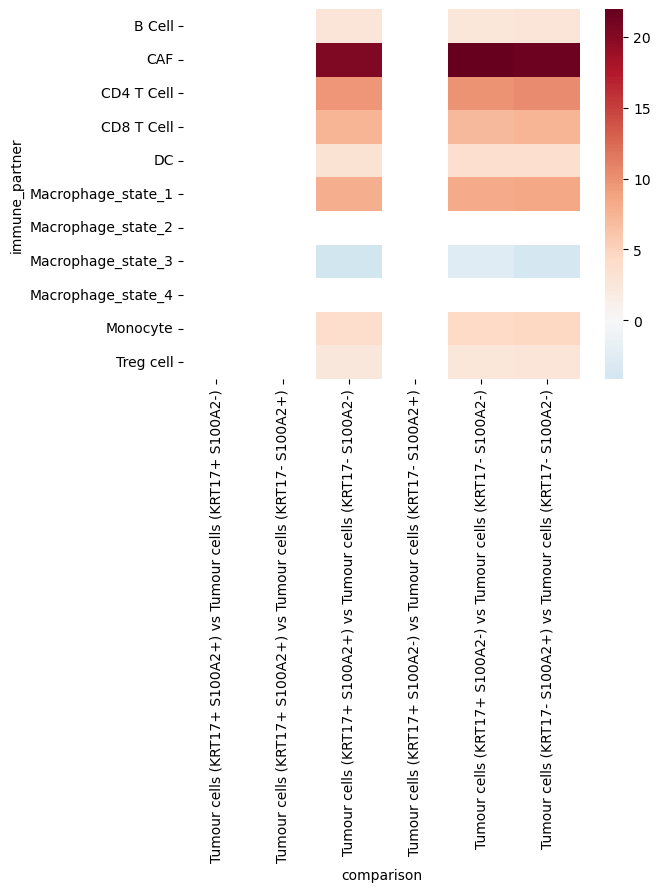

In [354]:
import numpy as np
results["significant"] = results["significant"].astype(bool)


sig = results.pivot_table(
    index="immune_partner",
    columns="comparison",
    values="significant",
    aggfunc="first"
)

heat = results.pivot_table(
    index="immune_partner",
    columns="comparison",
    values="z"
)

heat_masked = heat.mask(~sig)

sns.heatmap(
    heat_masked,
    cmap="RdBu_r",
    center=0
)

In [355]:
from pathlib import Path

# je génère des heatmap individuelles avec les comparaions statistiques, j'affiche différence d'assorattivité et si diffiréence est significative ou pas

save_dir_heatmap = Path(plot_save_dir) / f"comparaisons/{celltype}" / "heatmaps"

save_dir_heatmap.mkdir(parents=True, exist_ok=True)

for partner in imune_partners :
    plot_assortativity_heatmap(results, partner, figsize=(9, 7))
    plt.savefig(
    save_dir_heatmap / f"heatmap_assortativity_diff_{celltype}_and_{partner}.png",
    dpi=300,
    bbox_inches="tight")
    plt.close()


In [356]:
# je génère box plot des assorattivités et des braquettes quand différence significative ou pas
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator

assortativity_col = "assortativity"
tumor_col = "celltype_interest"
partner_col = "immune_partner"

immune_partners = stats_df[partner_col].unique()   # liste de tous les partners


for partner in immune_partners:

    df = stats_df.copy()

    plot_df = df[df[partner_col] == partner].copy()

    # éviter les plots vides
    if plot_df.empty:
        continue


    # Palette automatique
    celltypes = plot_df[tumor_col].unique()
    colors = sns.color_palette("husl", n_colors=len(celltypes))

    palette = dict(zip(celltypes, colors))


    fig, ax = plt.subplots(figsize=(5,7))


    sns.boxplot(
        data=plot_df,
        x=tumor_col,
        y=assortativity_col,
        width=0.5,
        showfliers=False,
        palette=palette,
        ax=ax
    )


    # Comparaisons significatives
    sig = results[
        (results["immune_partner"] == partner)
        &
        (results["padj"] < 0.05)
    ]


    pairs = []
    pvalues = []


    for _, row in sig.iterrows():

        a, b = row["comparison"].split(" vs ")

        pairs.append((a, b))
        pvalues.append(row["padj"])


    # Annotation p-values
    if len(pairs) > 0:

        annot = Annotator(
            ax,
            pairs,
            data=plot_df,
            x=tumor_col,
            y=assortativity_col
        )

        annot.configure(
            test=None,
            text_format="star",
            loc="inside",
            fontsize=12,
            line_height=0.01
        )

        annot.set_pvalues(pvalues)

        annot.annotate()


    # Labels
    ax.set_ylabel(
        "Assortativity z-scores",
        fontsize=14
    )

    ax.set_xlabel("")


    ax.set_title(
        f"Assortativity z-score comparison - {partner}",
        fontsize=16,
        pad=15
    )


    ax.tick_params(
        axis="y",
        labelsize=12
    )

    ax.tick_params(
        axis="x",
        labelsize=14
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=35,
        ha="right"
    )


    plt.tight_layout()

        # Dossier de sauvegarde
   

    save_dir_boxplot = Path(plot_save_dir) / "comparaisons" / celltype / "boxplot" 
    save_dir_boxplot.mkdir(parents=True, exist_ok=True)

    # Nom du fichier
    filename = f"Assortativity_Zscore_{partner.replace(' ', '_').replace('/', '_')}.png"

    save_path = save_dir_boxplot / filename

    # Sauvegarde
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2-): Custom statistical test, P_val:1.722e-02
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17- S100A2+): Custom statistical test, P_val:1.451e-02
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2+): Custom statistical test, P_val:1.331e-02


/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2-): Custom statistical test, P_val:6.769e-22
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17- S100A2+): Custom statistical test, P_val:3.789e-24
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2+): Custom statistical test, P_val:5.278e-21


/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


...

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2-): Custom statistical test, P_val:1.729e-02
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17- S100A2+): Custom statistical test, P_val:1.331e-02
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2+): Custom statistical test, P_val:2.824e-02


/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2-): Custom statistical test, P_val:1.760e-15
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17- S100A2+): Custom statistical test, P_val:1.060e-16
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2+): Custom statistical test, P_val:7.453e-15


/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7750/487831294.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2-): Custom statistical test, P_val:2.184e-02
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17- S100A2+): Custom statistical test, P_val:6.358e-04
Tumour cells (KRT17- S100A2-) vs. Tumour cells (KRT17+ S100A2+): Custom statistical test, P_val:1.656e-04
